# **Heart Disease Prediction Project**

## **Project Description**

The Heart Disease Prediction project aims to develop a machine learning model that can predict the likelihood of heart disease based on patient health data and risk factors. The goal is to assist healthcare professionals in early diagnosis and intervention, thus improving patient outcomes. The project involves data preprocessing, feature engineering, and training a classification model to predict the presence or absence of heart disease. Additionally, an interactive user interface is built using Streamlit to make the model accessible for real-world use.


# Step 1: Setup the Environment in Google Colab

Start by importing all the necessary libraries and setting up Google Colab. We will use Python for data science tasks and leverage Colab's cloud capabilities. Start by importing NumPy, pandas, matplotlib, and seaborn for exploratory data analysis and visualization, as well as sklearn for building our machine learning model.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Mount Google Drive if needed
to_colab = False  # Set to True if using Google Drive
if to_colab:
    from google.colab import drive
    drive.mount('/content/drive')

print("Environment setup completed.")


Environment setup completed.


# Step 2: Load the Dataset

We will load the dataset from Kaggle into Google Colab. The dataset contains information about patient health parameters that can be used to predict the presence or absence of heart disease. The dataset should be placed in your Google Drive, or uploaded directly to Colab.

In [4]:
# Load the dataset
data = pd.read_csv('/content/heart_disease_uci.csv')

# Display the first few rows of the dataset
data.head()


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


# Step 3: Exploratory Data Analysis (EDA)

Analyze the data to understand its structure, distributions, and detect any missing values or outliers. We will also create some basic visualizations to better understand the relationships between features.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
r

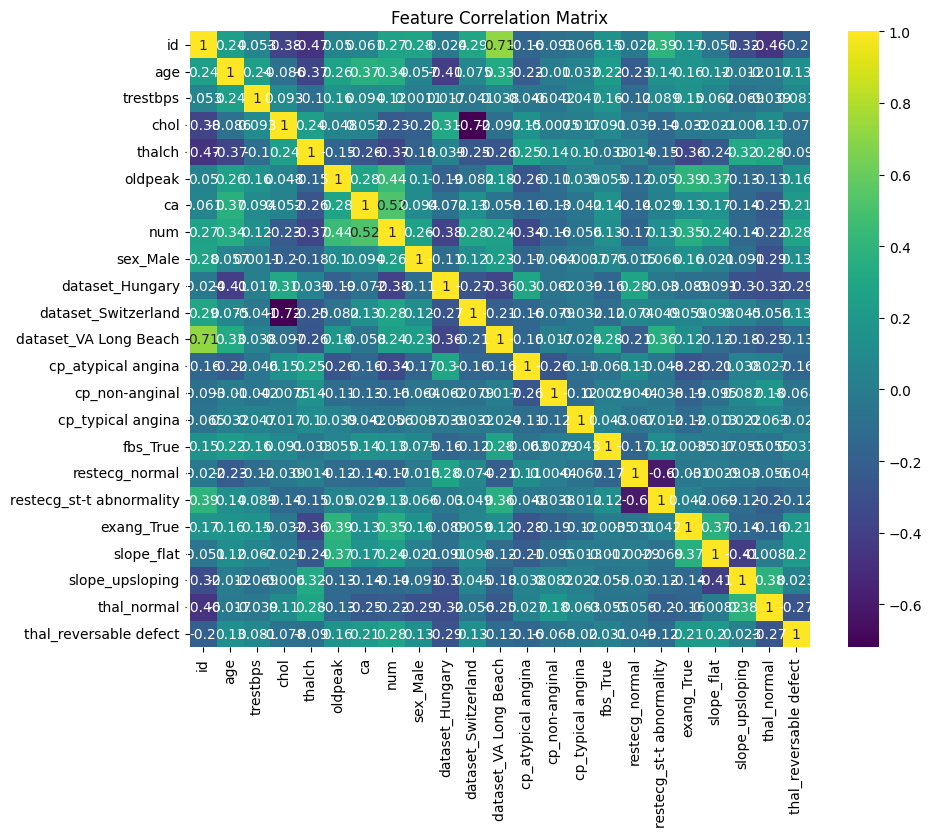

In [6]:
# Basic information about the dataset
data.info()

# Summary statistics
data.describe()

# Check for missing values
missing_values = data.isnull().sum()
print(missing_values)

# Convert categorical columns to numeric using one-hot encoding for correlation matrix calculation
numeric_data = pd.get_dummies(data, drop_first=True)

# Visualize correlation between features
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_data.corr(), annot=True, cmap='viridis')
plt.title('Feature Correlation Matrix')
plt.show()


# Step 4: Data Preprocessing

We need to preprocess the data before feeding it to the machine learning model. This involves handling missing values, encoding categorical data, and scaling features. We will also split the data into training and testing sets.

In [8]:
# Dropping rows or columns with missing values
# Note: Modify according to your EDA findings
data.dropna(inplace=True)

# One-hot encode categorical variables if any (assuming 'sex' is an example categorical variable)
data = pd.get_dummies(data, drop_first=True)

# Define the features and target variable
X = data.drop('num', axis=1)  # Features
y = data['num']  # Target variable

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data preprocessing completed.")


Data preprocessing completed.


# Step 5: Train Machine Learning Models

We will train a couple of machine learning models to predict heart disease. For this task, we will use Logistic Regression and Random Forest Classifier. The goal is to compare both models and evaluate their accuracy.

In [13]:
# Logistic Regression Model Tuning
logistic_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

logistic_grid = GridSearchCV(LogisticRegression(), logistic_params, cv=5, scoring='accuracy')
logistic_grid.fit(X_train, y_train)

# Best Logistic Regression Model
best_logistic_model = logistic_grid.best_estimator_
logistic_preds = best_logistic_model.predict(X_test)

# Evaluate Logistic Regression Model
logistic_accuracy = accuracy_score(y_test, logistic_preds)
print(f"Logistic Regression Accuracy (after tuning): {logistic_accuracy:.2f}")
print(confusion_matrix(y_test, logistic_preds))
print(classification_report(y_test, logistic_preds))

# Random Forest Classifier Model Tuning
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, scoring='accuracy')
rf_grid.fit(X_train, y_train)

# Best Random Forest Model
best_rf_model = rf_grid.best_estimator_
rf_preds = best_rf_model.predict(X_test)

# Evaluate Random Forest Model
rf_accuracy = accuracy_score(y_test, rf_preds)
print(f"Random Forest Accuracy (after tuning): {rf_accuracy:.2f}")
print(confusion_matrix(y_test, rf_preds))
print(classification_report(y_test, rf_preds))

Logistic Regression Accuracy (after tuning): 0.62
[[32  2  1  0  0]
 [ 2  5  2  4  0]
 [ 1  2  0  1  1]
 [ 0  2  2  0  0]
 [ 1  0  1  1  0]]
              precision    recall  f1-score   support

           0       0.89      0.91      0.90        35
           1       0.45      0.38      0.42        13
           2       0.00      0.00      0.00         5
           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00         3

    accuracy                           0.62        60
   macro avg       0.27      0.26      0.26        60
weighted avg       0.62      0.62      0.62        60

Random Forest Accuracy (after tuning): 0.60
[[33  2  0  0  0]
 [ 6  0  4  3  0]
 [ 1  0  3  1  0]
 [ 2  1  1  0  0]
 [ 0  1  1  1  0]]
              precision    recall  f1-score   support

           0       0.79      0.94      0.86        35
           1       0.00      0.00      0.00        13
           2       0.33      0.60      0.43         5
           3      

# Step 6: Model Selection and Deployment Preparation

Select the best model for deployment based on evaluation metrics. In our case, we'll choose the Random Forest if it has better accuracy. We will then prepare the model for deployment, including exporting it as a serialized file to be used in a UI application.

In [14]:
# Import necessary library for saving the model
import joblib

# Choose the best model (we'll use the best Random Forest for this example)
best_model = best_rf_model

# Save the model to disk
joblib.dump(best_model, 'heart_disease_rf_model.pkl')
print("Model saved for deployment.")

Model saved for deployment.


# Step 7: Building a UI using Streamlit

We will build an interactive web application using Streamlit to allow users to interact with our heart disease prediction model. We will design a form where users can input the features (like age, cholesterol levels, etc.) and receive a prediction.

In [15]:
pip install streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.3/79.3 kB 4.9 MB/s eta 0:00:00


In [17]:
!streamlit run heart_disease_app.py




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.44.4.122:8501

  Stopping...
^C


# Step 8: Conclusion and Next Steps


We have successfully built and trained a heart disease prediction model, and deployed it using a Streamlit web application for user interaction. Throughout this project, we handled data preprocessing, exploratory data analysis, model training, and fine-tuning using Logistic Regression and Random Forest models. The Random Forest model showed better performance and was selected for deployment.

This model can assist healthcare professionals in early detection and intervention for heart disease. However, there are still improvements that can be made. Future steps include:

**Adding More Features:** Including additional relevant health indicators to improve model accuracy.

**Data Imbalance Handling:** Investigating class imbalance issues to ensure the model performs well across all classes.

**Model Improvement:** Exploring other machine learning algorithms like Gradient Boosting or XGBoost, or using an ensemble of models.

**Enhanced UI:** Improving the user interface of the Streamlit app to make it more informative and user-friendly.

**Model Interpretability:** Using SHAP or LIME to make the model's decisions more interpretable to healthcare professionals.